[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mouryarahul/7CS107_PracticalWorks_Assignment/blob/master/Week9_Practical_Assignment_Part2.ipynb)


# Week 9 Practical Assignment Part-2 (Transfer Learning)

## Learning Objectives
By completing this assignment, you will:
- Apply **Transfer Learning (Feature Extraction)** with **ResNet-18** for the **Hymenoptera (Bees vs Ants)** dataset.  
- Explore and report how **hyperparameters** affect performance.

> **Academic Honesty:** You may discuss ideas with peers; however, all code you submit must be your own. Cite any external resources you use.



## Environment & Requirements
- Python 3.8+
- Packages: `numpy`, `matplotlib`, `torch`, `torchvision`, `tqdm`, `scikit-learn` (for evaluation)
- GPU is optional but recommended for Part 3.

> If you are running on university machines or Colab, ensure the above libraries are available. For local runs, install via `pip install -U numpy matplotlib torch torchvision tqdm scikit-learn`.



---
# Task 3 — Transfer Learning (Feature Extraction) with ResNet-18 on Hymenoptera (Bees vs Ants) (60 Marks)

In this section, you will implement **feature extraction** using **ResNet-18** pretrained on ImageNet to classify images of **bees** and **ants**.

**What you will do:**
1. Load the Hymenoptera dataset (bees vs ants).  
2. Define data transforms (augmentation for train, standardization for val/test).  
3. Load `resnet18(pretrained=True)`, **freeze** all backbone parameters, and **replace the final FC layer** with a 2-class classifier.  
4. Train only the classifier head.  
5. Experiment with **hyperparameters** (LR, weight decay, optimizer, batch size, augmentation) and report accuracy and confusion matrix.

> **Dataset**: Nanually place the extracted folder `hymenoptera_data/` under `./data/` with subfolders `train/ants`, `train/bees`, `val/ants`, `val/bees`.

**On Google Colab, please chose a Nividia GPU in the Runtime environment. This is make the training faster.**


In [3]:

# Import necessary libraries
import os, time, copy
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, utils
from torchvision.transforms import v2
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import itertools
from typing import Dict

# For reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Check for available GPU devices otherwise use CPU
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    DEVICE = torch.device('cuda')
    torch.cuda.manual_seed_all(SEED)
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print('Using device:', DEVICE)


Using device: cuda


In [4]:
# Download hymenoptera dataset
!wget https://download.pytorch.org/tutorial/hymenoptera_data.zip

# Unzip
!unzip -q hymenoptera_data.zip

--2026-08-25 09:48:51--  https://download.pytorch.org/tutorial/hymenoptera_data.zip
Resolving download.pytorch.org (download.pytorch.org)... 65.8.76.123, 65.8.76.80, 65.8.76.30, ...
Connecting to download.pytorch.org (download.pytorch.org)|65.8.76.123|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 47286322 (45M) [application/zip]
Saving to: ‘hymenoptera_data.zip’

hymenoptera_data.zi 100%[===================>]  45.10M   164MB/s    in 0.3s    

2026-08-25 09:48:52 (164 MB/s) - ‘hymenoptera_data.zip’ saved [47286322/47286322]




## 3.1 Load Hymenoptera Dataset
This cell attempts to **download** the dataset from the PyTorch tutorial mirror. If download is not available, it will expect the folder structure:
```
./hymenoptera_data/
  ├── train/
  │   ├── ants/
  │   └── bees/
  └── val/
      ├── ants/
      └── bees/
```


In [5]:

# Dataset paths
data_root = os.path.join('hymenoptera_data')
train_dir = os.path.join(data_root, 'train')
val_dir   = os.path.join(data_root, 'val')


BATCH_SIZE = 16
NUM_WORKERS =  0
IMG_SIZE = 224
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
PIN_MEMORY = DEVICE.type == "cuda"
# Define transforms for Training Data: this is doing data augmentation and normalization
train_tfms = v2.Compose([
    v2.RandomResizedCrop(IMG_SIZE),
    v2.RandomHorizontalFlip(),
    #v2.ToTensor(),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean, std)
])
# Define transforms for Validation Data: only resizing and normalization
val_tfms = v2.Compose([
    v2.Resize(256),
    v2.CenterCrop(IMG_SIZE),
    # v2.ToTensor(),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean, std)
])

# Check if dataset exists
if not os.path.isdir(train_dir) or not os.path.isdir(val_dir):
    print('⚠️  Dataset not found at', data_root)
    print('Please place the hymenoptera_data folder under ./data/ as documented above.')

# Build datasets and loaders
train_ds = datasets.ImageFolder(train_dir, transform=train_tfms)
val_ds   = datasets.ImageFolder(val_dir,   transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=NUM_WORKERS)

class_names = train_ds.classes
print('Classes:', class_names)
print('Train images:', len(train_ds), '| Val images:', len(val_ds))

Classes: ['ants', 'bees']
Train images: 244 | Val images: 153



## 3.2 Visualize a Few Training Images


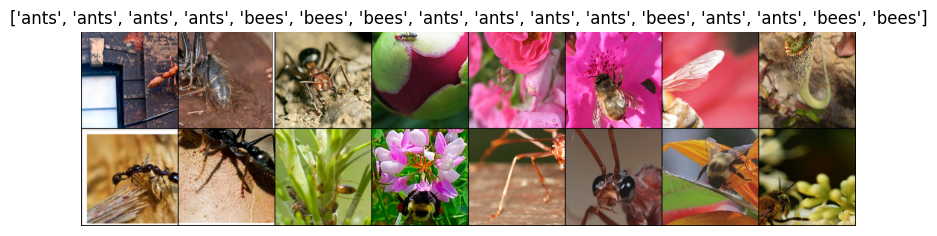

In [6]:

# Visualize a grid of images
inv_norm = v2.Normalize(
    mean=[-m/s for m, s in zip(mean,std)],
    std=[1/s for s in std]
)

def imshow_grid(inputs, title=None, nrow=8):
    inp = inputs.detach().cpu()
    # Undo normalization for visualization
    for i in range(inp.size(0)):
        inp[i] = inv_norm(inp[i])
    grid = torch.clamp(utils.make_grid(inp, nrow=nrow), 0, 1)
    plt.figure(figsize=(10, 5))
    plt.axis('off')
    if title is not None:
        plt.title(title)
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.show()

# Fetch a batch
images, labels = next(iter(train_loader))
imshow_grid(images[:16], title=[class_names[l] for l in labels[:16]], nrow=8)



## 3.3 Build ResNet-18 (Feature Extraction)
- Load `resnet18(pretrained=True)`
- **Freeze** all backbone layers
- Replace the final fully-connected layer with `nn.Linear(in_features, 2)`


In [7]:
# Set location for downloaded pretrained weights
%env TORCH_HOME=pretrained_models

# Load ResNet-18 with pretrained ImageNet weights
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Freeze all pretrained backbone parameters
for parameter in model.parameters():
    parameter.requires_grad = False

# Replace the original 1000-class layer with a 2-class layer
number_of_features = model.fc.in_features
model.fc = nn.Linear(
    in_features=number_of_features,
    out_features=2
)

# Move the model to GPU or CPU
model = model.to(DEVICE)

print(model.fc)

env: TORCH_HOME=pretrained_models
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to pretrained_models/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


Linear(in_features=512, out_features=2, bias=True)



## 3.4 Define Loss, Optimizer, and Scheduler
- Use `CrossEntropyLoss`
- Choose an optimizer for **only the classifier head parameters** (e.g., SGD/Adam)
- Optionally, use a learning-rate scheduler such as `StepLR`


In [8]:

# TODO: Hyperparameters (feel free to tune)
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 15
OPTIMIZER = 'adam'  # 'sgd' or 'adam'

# Define Loss function, optimizer, and scheduler
criterion = nn.CrossEntropyLoss()

# Only params of final layer are being optimized
params_to_update = [p for p in model.parameters() if p.requires_grad]

if OPTIMIZER.lower() == 'sgd':
    optimizer = optim.SGD(params_to_update, lr=LR, momentum=0.9, weight_decay=WEIGHT_DECAY)
else:
    optimizer = optim.Adam(params_to_update, lr=LR, weight_decay=WEIGHT_DECAY)

# Define a learning rate scheduler (you can fine-tune the parameters like step_size and gamma)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)



## 3.5 Training & Evaluation Utilities


In [9]:
def train_model(
    model,
    criterion,
    optimizer,
    scheduler,
    num_epochs=EPOCHS
):
    """Train and validate the model."""
    since = time.time()

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_model_weights = copy.deepcopy(
        model.state_dict()
    )
    best_accuracy = 0.0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            # Select the correct mode and data loader
            if phase == "train":
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_correct = 0

            for inputs, labels in tqdm(
                dataloader,
                desc=phase
            ):
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                # Clear gradients from the previous batch
                optimizer.zero_grad(set_to_none=True)

                # Enable gradients only during training
                with torch.set_grad_enabled(
                    phase == "train"
                ):
                    outputs = model(inputs)
                    predictions = torch.argmax(
                        outputs,
                        dim=1
                    )

                    loss = criterion(
                        outputs,
                        labels
                    )

                    # Update parameters during training only
                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                # Accumulate batch statistics
                running_loss += (
                    loss.item()*inputs.size(0)
                )

                running_correct += (
                    predictions == labels
                ).sum().item()

            # Update learning rate after training phase
            if phase == "train" and scheduler is not None:
                scheduler.step()

            dataset_size = len(dataloader.dataset)

            epoch_loss = (
                running_loss/dataset_size
            )

            epoch_accuracy = (
                running_correct/dataset_size
            )

            print(
                f"{phase} Loss: {epoch_loss:.4f} "
                f"Acc: {epoch_accuracy:.4f}"
            )

            # Save training or validation history
            history[f"{phase}_loss"].append(
                epoch_loss
            )
            history[f"{phase}_acc"].append(
                epoch_accuracy
            )

            # Save the best validation model
            if (
                phase == "val"
                and epoch_accuracy > best_accuracy
            ):
                best_accuracy = epoch_accuracy
                best_model_weights = copy.deepcopy(
                    model.state_dict()
                )

    elapsed_time = time.time() - since

    print(
        f"Training complete in "
        f"{elapsed_time // 60:.0f}m "
        f"{elapsed_time % 60:.0f}s"
    )

    print(
        f"Best validation accuracy: "
        f"{best_accuracy:.4f}"
    )

    # Restore the best validation weights
    model.load_state_dict(best_model_weights)

    return model, history

### Helper Functions to Plot Loss and Accuracy history over epoces

In [10]:
def plot_curves(history: Dict[str, list]):
    '''Plot training and validation loss and accuracy curves.'''
    epochs = range(1, len(history['train_loss'])+1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], label='Train')
    plt.plot(epochs, history['val_loss'], label='Val')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss'); plt.legend();
    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_acc'], label='Train')
    plt.plot(epochs, history['val_acc'], label='Val')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy'); plt.legend();
    plt.show()


def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix'):
    '''This function prints and plots the confusion matrix.'''
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

Epoch 1/15
----------


train:   0%|          | 0/16 [00:00<?, ?it/s]

train Loss: 0.6351 Acc: 0.6475


val:   0%|          | 0/10 [00:00<?, ?it/s]

val Loss: 0.4156 Acc: 0.8627
Epoch 2/15
----------


...

val Loss: 0.1852 Acc: 0.9412
Epoch 15/15
----------


train:   0%|          | 0/16 [00:00<?, ?it/s]

train Loss: 0.2117 Acc: 0.9262


val:   0%|          | 0/10 [00:00<?, ?it/s]

val Loss: 0.1868 Acc: 0.9412
Training complete in 0m 49s
Best validation accuracy: 0.9477


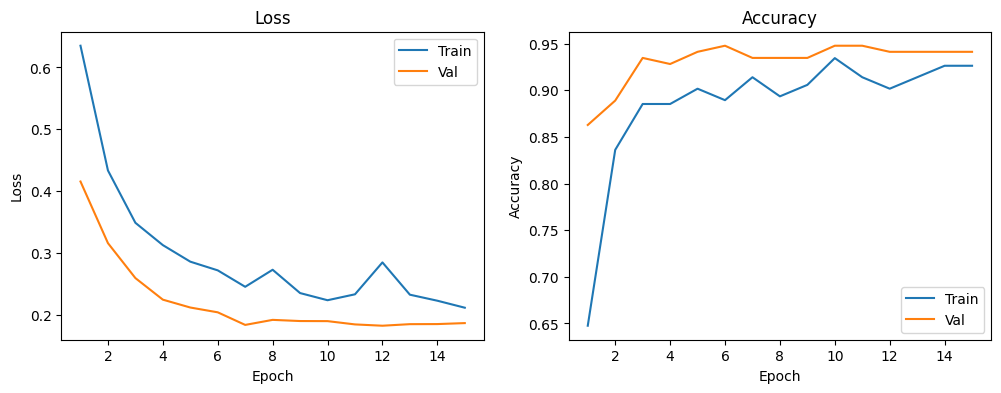

Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Final Accuracy: 0.9477
              precision    recall  f1-score   support

        ants       0.92      0.97      0.94        70
        bees       0.97      0.93      0.95        83

    accuracy                           0.95       153
   macro avg       0.95      0.95      0.95       153
weighted avg       0.95      0.95      0.95       153



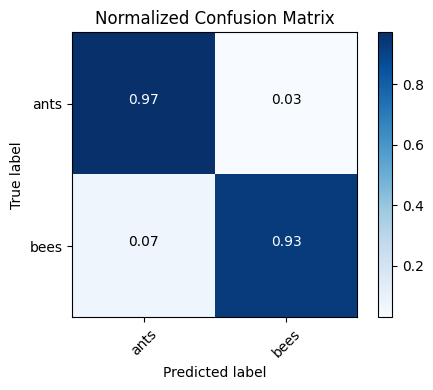

In [11]:
# Train the classifier head
final_model, history = train_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=15
)

# Save the trained model
os.makedirs("trained_model", exist_ok=True)

torch.save(
    final_model.state_dict(),
    "trained_model/hymenoptera_resnet18_finetuned.pth"
)

# Plot training and validation curves
plot_curves(history)


# Evaluate the trained model on the validation set
final_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(
        val_loader,
        desc="Evaluating"
    ):
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        # Calculate model outputs
        outputs = final_model(inputs)

        # Select the class with the highest output score
        _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# Calculate final validation accuracy
final_accuracy = accuracy_score(
    all_labels,
    all_preds
)

print(f"Final Accuracy: {final_accuracy:.4f}")


# Plot normalized confusion matrix
cm = confusion_matrix(
    all_labels,
    all_preds
)

plot_confusion_matrix(
    cm,
    classes=class_names,
    normalize=True,
    title="Normalized Confusion Matrix"
)


# Print precision, recall and F1-score
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)